**DS5216 Artificial Intelligence: Programming Assignment II: DTS2433: R. D. Y. vimukthi**

**Notebook 2: Model training and Evaluation using YOLOv8**


 **Instructions:**

*   Please upload the "cricket-player-detection" folder (which is shared in GitHub) before executing the following colab file. The folder contains three sub-folders train, valid, and test, each containing two sub-folders. One for images and one for annotated labels with 5 values for each bounding box (class and 4 corner values of the bounding box)
*   data.yaml file is available in the current directory (already available with the dataset)
*   Dependencies are installed, libraries are imported
*   Include videos for testing (detecting players on a video stream) in "videos" folder in the current directory

**Installing dependencies, and importing required libraries**

In [1]:
!pip -q install ultralytics
!pip -q install matplotlib seaborn pandas opencv-python

print("Libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.8 MB/s eta 0:00:00
Libraries installed successfully.


In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
sns.set(style="whitegrid")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("Warning: Running on CPU (training will be slow)")

CUDA Available: True
GPU Name: Tesla T4


**Loading the dataset**

In [4]:
USE_DRIVE = True

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
USE_DRIVE = True

if USE_DRIVE:
    DATASET_PATH = "/content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection"
else:
    DATASET_PATH = "/content/cricket-player-detection"

print("Dataset Path:", DATASET_PATH)

Dataset Path: /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection


**Loading the YOLOv8 model with pre-trained COCO weights and training**

In [6]:
model = YOLO("yolov8n.pt")

print("Model loaded successfully.")

Model loaded successfully.


In [7]:
results = model.train(
    data=os.path.join(DATASET_PATH, "data.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="cricket_yolo_runs",
    name="yolov8_cricket_players",
    exist_ok=True
)

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_cricket_players, nbs=64, nms=Fals

In [8]:
results_path = "/content/runs/detect/cricket_yolo_runs/yolov8_cricket_players/results.csv"
df = pd.read_csv(results_path)
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,25.7606,1.45756,2.90198,1.12647,0.00727,0.87500,0.45160,0.28361,1.31717,3.21148,1.06549,0.000260,0.000260,0.000260
1,2,31.4723,1.43987,1.80917,1.13630,0.00743,0.89474,0.15353,0.10377,1.29845,3.26912,1.11340,0.000529,0.000529,0.000529
2,3,36.7526,1.48843,1.68833,1.22902,0.45049,0.02176,0.04834,0.02412,1.45018,3.39559,1.25376,0.000788,0.000788,0.000788
3,4,41.4180,1.43790,1.56248,1.18778,0.33067,0.11842,0.11116,0.05892,1.47913,3.20040,1.24879,0.001035,0.001035,0.001035
4,5,48.2791,1.43413,1.54219,1.18949,0.20085,0.18189,0.10782,0.05430,1.61771,2.97986,1.32244,0.001271,0.001271,0.001271


**Evaluations and Visualizations**

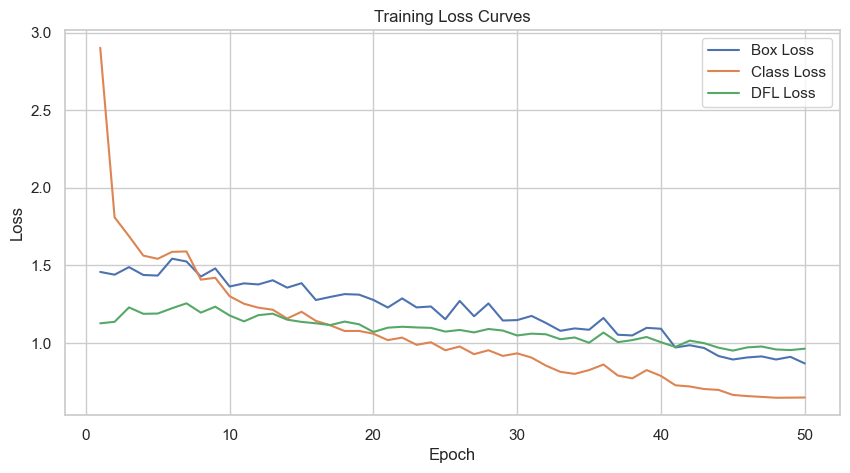

In [9]:
#Loss Curves - Training loss curve
plt.figure(figsize=(10,5))

plt.plot(df["epoch"], df["train/box_loss"], label="Box Loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="Class Loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="DFL Loss")

plt.title("Training Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

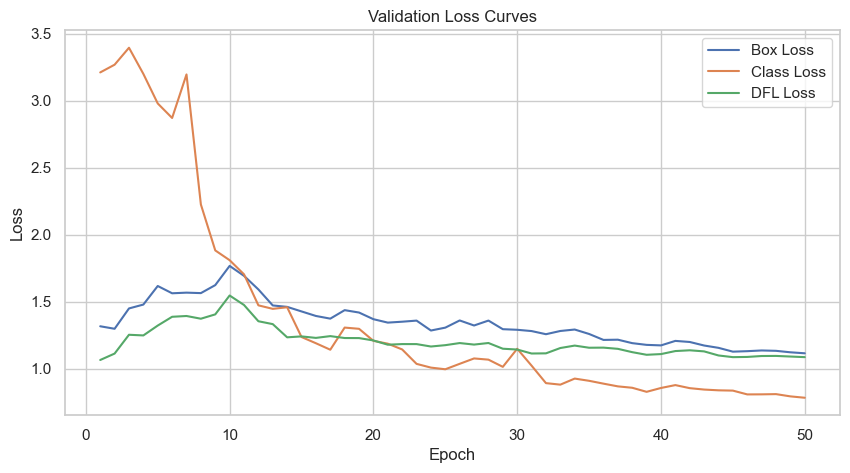

In [10]:
#Validation Loss Curve

plt.figure(figsize=(10,5))
plt.plot(df["epoch"], df["val/box_loss"], label="Box Loss")
plt.plot(df["epoch"], df["val/cls_loss"], label="Class Loss")
plt.plot(df["epoch"], df["val/dfl_loss"], label="DFL Loss")
plt.title("Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


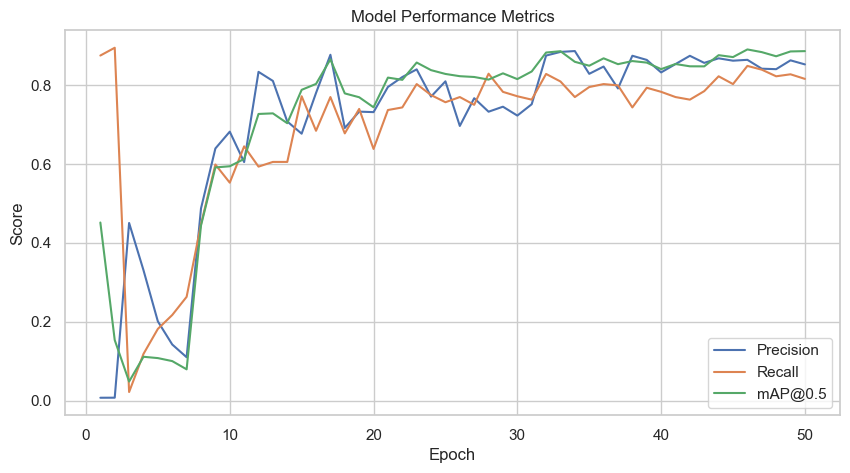

In [11]:
#Precision, Recall, and mAP curves
plt.figure(figsize=(10,5))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
plt.title("Model Performance Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()

In [12]:
#Confusion Matrix
metrics = model.val(data=os.path.join(DATASET_PATH, "data.yaml"))

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 14.4±3.5 MB/s, size: 27.5 KB)
val: Scanning /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection/valid/labels.cache... 61 images, 23 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 61/61 23.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.4it/s 2.9s
                   all         61        152      0.843      0.849      0.883      0.591
Speed: 6.4ms preprocess, 10.1ms inference, 0.0ms loss, 6.0ms postprocess per image
Results saved to /content/runs/detect/val


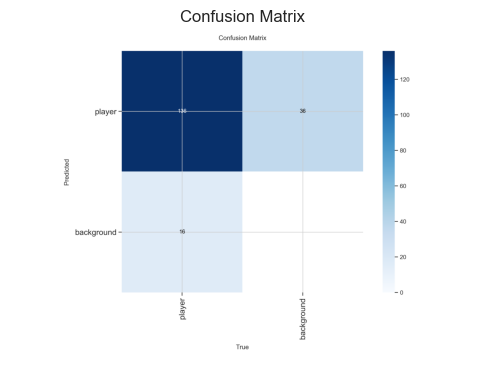

In [13]:
import matplotlib.image as mpimg

img = mpimg.imread("runs/detect/val/confusion_matrix.png")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

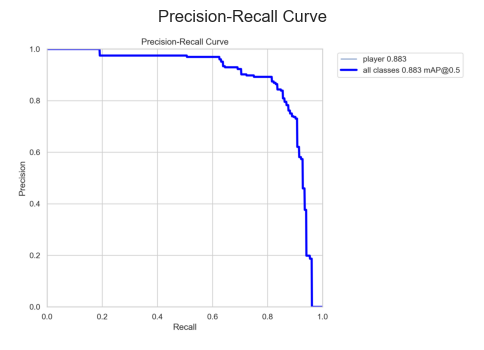

In [14]:
#Precisio-Recall Curve
img = mpimg.imread("runs/detect/val/BoxPR_curve.png")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Precision-Recall Curve")
plt.show()

In [15]:
import os

# List the contents of the validation run directory
val_run_dir = "runs/detect/val/"
print(f"Contents of '{val_run_dir}':")
for item in os.listdir(val_run_dir):
    print(item)

Contents of 'runs/detect/val/':
val_batch1_labels.jpg
val_batch0_labels.jpg
confusion_matrix.png
val_batch2_pred.jpg
BoxR_curve.png
BoxP_curve.png
val_batch0_pred.jpg
BoxPR_curve.png
confusion_matrix_normalized.png
val_batch2_labels.jpg
val_batch1_pred.jpg
BoxF1_curve.png


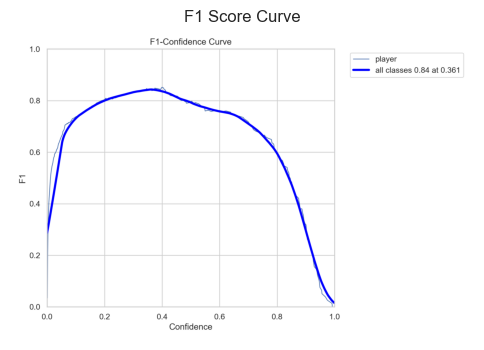

In [16]:
#F1 curve
img = mpimg.imread("runs/detect/val/BoxF1_curve.png")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("F1 Score Curve")
plt.show()

**Model Evaluation on Test data**

Players detected with bounding boxes on test data will be saved in "content/runs/detect/predict"

In [17]:
test_images = os.path.join(DATASET_PATH, "test/images")

test_results = model.predict(
    source=test_images,
    save=True,
    conf=0.4
)

print("Test inference completed.")


image 1/31 /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection/test/images/cricket10_mp4-0003_jpg.rf.5b5aa1b09aec697ddfe259e6ec8a58ce.jpg: 640x640 (no detections), 11.2ms
image 2/31 /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection/test/images/cricket10_mp4-0015_jpg.rf.cc0f1fea5970311ba2ee51b50b20a44f.jpg: 640x640 2 players, 7.3ms
image 3/31 /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection/test/images/cricket10_mp4-0021_jpg.rf.b49d715ef1ea6cfbdc82e29ed467d650.jpg: 640x640 7 players, 7.2ms
image 4/31 /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection/test/images/cricket10_mp4-0022_jpg.rf.414accaf698faf00fed7b6fbe1141ecd.jpg: 640x640 4 players, 7.3ms
image 5/31 /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection/test/images/cricket1_mp4-0022_jpg.rf.3d97336c79afd0732db86aff15ae8d89.jpg: 640x640 (no detections), 7.3ms
image 6/31 /content/dr

In [18]:
#Obtaining performance metrics for test set
test_metrics = model.val(
    data=os.path.join(DATASET_PATH, "data.yaml"),
    split="test"
)

print(test_metrics)

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 1.1±0.8 ms, read: 6.9±4.0 MB/s, size: 30.7 KB)
val: Scanning /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection/test/labels.cache... 31 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 6.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4s/it 2.8s
                   all         31         95      0.858      0.768      0.885      0.495
Speed: 19.3ms preprocess, 20.5ms inference, 0.0ms loss, 7.9ms postprocess per image
Results saved to /content/runs/detect/val-2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c7df05b8980>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Rec

Players detected with bounding boxes on a video stream (live detection) will be saved in "content/runs/detect/predict"

In [42]:
video_path = os.path.join(DATASET_PATH, "videos", "cricket5.mp4")

video_results = model.predict(
    source=video_path,
    save=True,
    conf=0.4
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/250) /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection/videos/cricket5.mp4: 384x640 5 players, 9.0ms
video 1/1 (frame 2/250) /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection/videos/cricket5.mp4: 384x640 5 players, 7.8ms
video 1/1 (frame 3/250) /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection/videos/cricket5.mp4: 384x640 5 players, 11.3ms
vide

In [43]:
import os

# List the contents of the validation run directory
val_run_dir = "runs/detect/predict/"
print(f"Contents of '{val_run_dir}':")
for item in os.listdir(val_run_dir):
    print(item)

Contents of 'runs/detect/predict/':
cricket8_mp4-0008_jpg.rf.c2afe012daf9c7229b09b7731e95ba26.jpg
cricket6_mp4-0019_jpg.rf.6131c11e609ad8d1c5fbbfa4d5c095f5.jpg
cricket7_mp4-0004_jpg.rf.180c1ac8080fa64d5126b7df50d726aa.jpg
cricket7_mp4-0029_jpg.rf.4ae2f0e23718dbabea43114a48deed6e.jpg
cricket3_mp4-0005_jpg.rf.41d565b9549e4ef99d9a9b20d4311d6a.jpg
cricket5_mp4-0005_jpg.rf.81b757d604054cbc85662ad54acdeae9.jpg
cricket1_mp4-0022_jpg.rf.3d97336c79afd0732db86aff15ae8d89.jpg
cricket8_mp4-0009_jpg.rf.d8401f8846577073af2438a939659de3.jpg
cricket7_mp4-0026_jpg.rf.35db3f2ad629a8513486a4bbd19c9549.jpg
cricket10_mp4-0003_jpg.rf.5b5aa1b09aec697ddfe259e6ec8a58ce.jpg
cricket2_mp4-0027_jpg.rf.1edddc328f94ae52fb1c810e668b6969.jpg
cricket9_mp4-0015_jpg.rf.d37cc4cfe0e1848851270aaf30ae78fe.jpg
cricket6_mp4-0016_jpg.rf.ebb98ac0ea48b5505e5bda78204f3ec6.jpg
cricket1_mp4-0030_jpg.rf.de425f494f0c17ed7f07153a65e4f118.jpg
cricket2_mp4-0026_jpg.rf.b958880a5aa820e9b9832101e62c8d33.jpg
cricket10_mp4-0022_jpg.rf.414acca

In [21]:
#Frames per second estimation
import time
import cv2
cap = cv2.VideoCapture(video_path)
start = time.time()
frames = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames += 1
end = time.time()
fps = frames / (end - start)
print("Approx FPS:", fps)

Approx FPS: 284.5343004959203


In [22]:
#Saving the best model
import shutil

best_model_path = "runs/detect/cricket_yolo_runs/yolov8_cricket_players/weights/best.pt"
shutil.copy(best_model_path, "best_cricket_yolo.pt")

print("Best model saved.")

Best model saved.


In [23]:
PROJECT_NAME = "Cricket_Player_Detection"
BEST_MODEL = "/content/runs/detect/cricket_yolo_runs/yolov8_cricket_players/weights/best.pt"
DATASET_PATH="/content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection"
OUTPUT="/content/final_results"

In [24]:
import shutil
plt.style.use("ggplot")

In [25]:
DATA_YAML = os.path.join(DATASET_PATH, "data.yaml")

In [26]:
folders = [
    "metrics",
    "plots",
    "tables",
    "image_predictions",
    "video_predictions",
    "report_figures",
    "frames"
]
for folder in folders:
    os.makedirs(
        os.path.join(OUTPUT, folder),
        exist_ok=True
    )
print("Folders created successfully.")

Folders created successfully.


In [27]:
#loading the best model weights for evaluations
model = YOLO(BEST_MODEL)
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

**Evaluation Comparisons: validation vs. testing**

In [28]:
print("="*60)
print("Running validation evaluation...")
print("="*60)

val_metrics = model.val(
    data=DATA_YAML,
    split="val",
    save_json=True,
    project=OUTPUT,
    name="validation"

)

Running validation evaluation...
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 16.2±4.0 MB/s, size: 28.4 KB)
val: Scanning /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection/valid/labels.cache... 61 images, 23 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 61/61 17.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.4it/s 2.9s
                   all         61        152      0.843      0.849      0.883      0.591
Speed: 10.0ms preprocess, 5.2ms inference, 0.0ms loss, 4.8ms postprocess per image
Saving /content/final_results/validation/predictions.json...
Results saved to /content/final_results/validation


**Evaluations on Test dataset**

In [29]:
print("="*60)
print("Running test evaluation...")
print("="*60)

test_metrics = model.val(
    data=DATA_YAML,
    split="test",
    save_json=True,
    project=OUTPUT,
    name="test"

)

Running test evaluation...
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 12.6±1.1 MB/s, size: 32.0 KB)
val: Scanning /content/drive/MyDrive/DS5216 AI Programming Assignment/cricket-player-detection/test/labels.cache... 31 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 8.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.3it/s 1.5s
                   all         31         95      0.858      0.768      0.885      0.495
Speed: 6.8ms preprocess, 5.5ms inference, 0.0ms loss, 2.9ms postprocess per image
Saving /content/final_results/test/predictions.json...
Results saved to /content/final_results/test


In [30]:
metrics_table = pd.DataFrame({
    "Metric":[
        "Precision",
        "Recall",
        "mAP@0.5",
        "mAP@0.5:0.95"
    ],
    "Validation":[
        val_metrics.box.mp,
        val_metrics.box.mr,
        val_metrics.box.map50,
        val_metrics.box.map
    ],
    "Test":[
        test_metrics.box.mp,
        test_metrics.box.mr,
        test_metrics.box.map50,
        test_metrics.box.map
    ]
})
metrics_table

,Metric,Validation,Test
0,Precision,0.842707,0.858309
1,Recall,0.848684,0.768421
2,mAP@0.5,0.883236,0.885447
3,mAP@0.5:0.95,0.591078,0.495440


In [31]:
metrics_csv = os.path.join(
    OUTPUT,
    "tables",
    "evaluation_metrics.csv"
)
metrics_table.to_csv(
    metrics_csv,
    index=False
)
print(metrics_table)

         Metric  Validation      Test
0     Precision    0.842707  0.858309
1        Recall    0.848684  0.768421
2       mAP@0.5    0.883236  0.885447
3  mAP@0.5:0.95    0.591078  0.495440


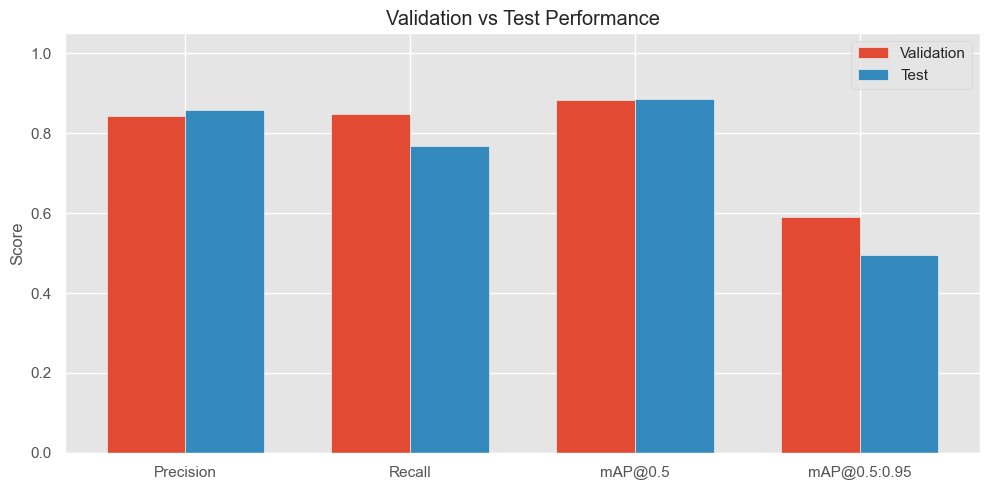

In [32]:
fig,ax = plt.subplots(
    figsize=(10,5)
)
x=np.arange(len(metrics_table))
width=0.35
ax.bar(
    x-width/2,
    metrics_table["Validation"],
    width,
    label="Validation"
)

ax.bar(
    x+width/2,
    metrics_table["Test"],
    width,
    label="Test"
)

ax.set_xticks(x)
ax.set_xticklabels(
    metrics_table["Metric"]
)

ax.set_ylim(0,1.05)
ax.set_ylabel("Score")
ax.set_title("Validation vs Test Performance")
ax.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT,
        "plots",
        "metric_comparison.png"
    ),

    dpi=300
)
plt.show()

In [33]:
display(
    metrics_table.style.background_gradient(cmap="Greens").format({"Validation": "{:.4f}", "Test": "{:.4f}"})
)

,Metric,Validation,Test
0,Precision,0.8427,0.8583
1,Recall,0.8487,0.7684
2,mAP@0.5,0.8832,0.8854
3,mAP@0.5:0.95,0.5911,0.4954


In [34]:
print("="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
for _,row in metrics_table.iterrows():
    print(
        f"{row['Metric']:15s}"
        f" Validation = {row['Validation']:.4f}"
        f" | Test = {row['Test']:.4f}"
    )
print("="*60)

MODEL PERFORMANCE SUMMARY
Precision       Validation = 0.8427 | Test = 0.8583
Recall          Validation = 0.8487 | Test = 0.7684
mAP@0.5         Validation = 0.8832 | Test = 0.8854
mAP@0.5:0.95    Validation = 0.5911 | Test = 0.4954


In [35]:
import glob
for eval_folder in ["validation", "test"]:
    source_dir = os.path.join(OUTPUT, eval_folder)
    for image_file in glob.glob(os.path.join(source_dir, "*.png")):
        shutil.copy(
            image_file,
            os.path.join(
                OUTPUT,
                "report_figures",
                f"{eval_folder}_{os.path.basename(image_file)}"
            )
        )
print("Evaluation figures copied to report_figures.")

Evaluation figures copied to report_figures.
